In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Experience và Education
X = np.array([[3, 12], [4, 13], [5, 14], [6, 15]])

# Thêm cột bias
X_bias = np.c_[np.ones(X.shape[0]), X]

# Salary thực tế
y = np.array([60, 55, 66, 93])

# [b, w1, w2] - khởi tạo tham số
theta = np.array([10, 3, 2])

print(f'Input shape: {X_bias.shape}')
print(f'Output shape: {y.shape}')
print(f'Theta shape: {theta.shape}')

Input shape: (4, 3)
Output shape: (4,)
Theta shape: (3,)


In [30]:
def predict(X, theta):
    return X.dot(theta)

def compute_loss(y_hat, y):
    N = y.shape[0]

    return np.sum((y_hat - y) ** 2) / N

def compute_gradient(y_hat, y, X):
    N = y.shape[0]
    k = 2 * (y_hat - y)

    return X.T.dot(k) / N

def update_gradient(theta, gradient, lr):
    theta = theta - lr * gradient

    return theta

In [31]:
# Before training prediction
X_test = np.array([[1, 4, 13]])
y_hat = predict(X_test, theta)
loss = compute_loss(y_hat, y)
print(f'Loss before training: {loss}')

Loss before training: 635.5


In [32]:
# Các thông số huấn luyện
epoch_max = 4
lr = 0.001  # Learning rate
N = len(y)
losses = []

# Huấn luyện qua các epoch
for epoch in range(epoch_max):
    # Dự đoán giá trị
    y_hat = predict(X_bias, theta)

    # Tính Loss (MSE) - Chia cho N
    loss = compute_loss(y_hat, y)
    losses.append(loss)

    # Tính gradient
    gradient = compute_gradient(y_hat, y, X_bias)

    # Cập nhật tham số
    theta = update_gradient(theta, gradient, lr)

    print(f'Epoch {epoch+1}: Loss = {loss}, theta = {theta}')

final_theta = theta
losses, final_theta

Epoch 1: Prediction = [43. 48. 53. 58.], Loss = 433.0, theta = [10.036  3.177  2.501]
Epoch 2: Prediction = [49.579 55.257 60.935 66.613], Loss = 207.64782100000002, theta = [10.056808  3.283941  2.795213]
Epoch 3: Prediction = [53.451187 59.530341 65.609495 71.688649], Loss = 129.43427922136902, theta = [10.06866816  3.34961385  2.96762733]
Epoch 4: Prediction = [55.72903767 62.04627885 68.36352003 74.68076122], Loss = 102.26797535859747, theta = [10.07525837  3.39097666  3.06830194]


([433.0, 207.64782100000002, 129.43427922136902, 102.26797535859747],
 array([10.07525837,  3.39097666,  3.06830194]))

In [33]:
# After training prediction
X_test = np.array([[1, 4, 13]])
y_hat = predict(X_test, theta)
loss = compute_loss(y_hat, y)
print(f'Loss after training: {loss}')

Loss after training: 239.97983168947812


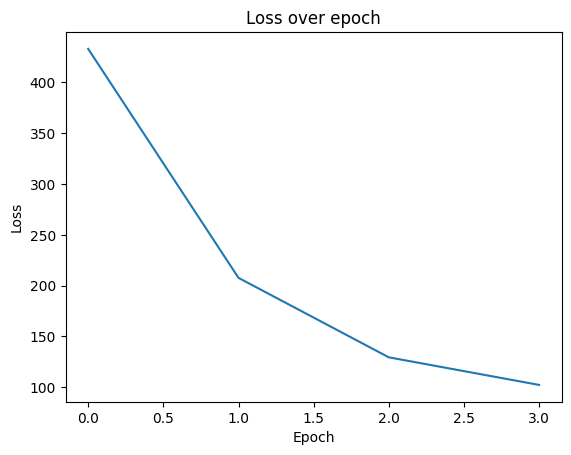

In [34]:
plt.plot(losses)
plt.title('Loss over epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()